In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import os

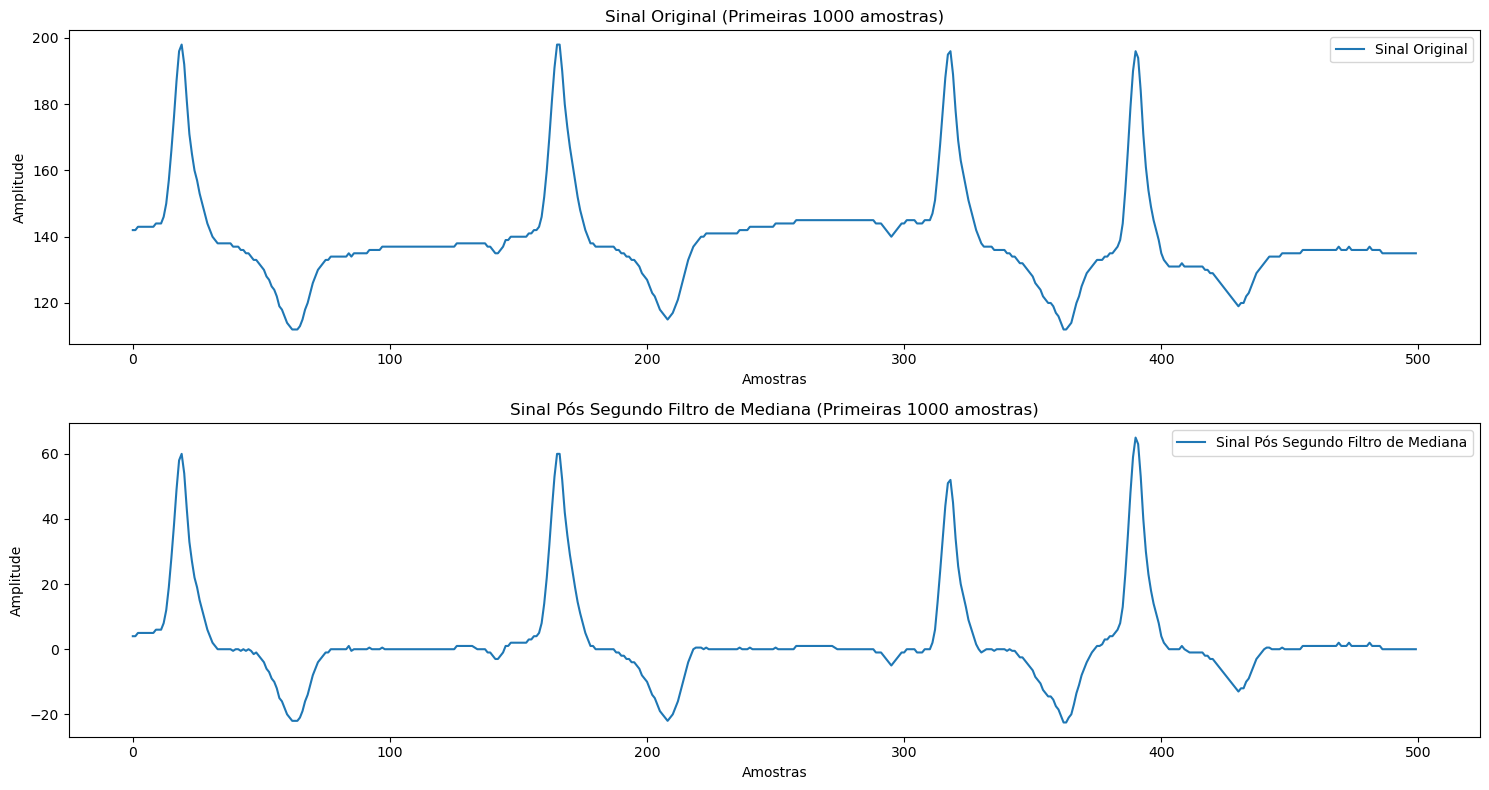

In [18]:
# Função de filtro de mediana ajustada
def median_filter(signal, window_size):
    rolling_median = pd.Series(signal).rolling(window=window_size, center=True).median()
    filled_series = rolling_median.bfill().ffill()
    return filled_series.values

# Função de pré-processamento ajustada para aplicar apenas o segundo filtro de mediana
def preprocess_signal_single_filter(signal, sample_rate=128):
    # Calculando tamanho de janela para a taxa de amostragem de 128 Hz
    window_size_600ms = int(0.6 * sample_rate)  # 600 ms em amostras

    signal_baseline = median_filter(signal, window_size_600ms)
    signal_preprocessed = signal - signal_baseline
    return signal_preprocessed

# Caminho do arquivo de ECG
file_path = "/home/leo-vitor/Documentos/UFC/biosinais/Exames_24h_recortados/0.0/067.txt"

# Carregar o sinal ECG do arquivo de texto
with open(file_path, 'r') as file:
    ecg_signal = [float(line.strip()) for line in file]

# Selecionar uma janela de 1000 amostras
window_size = 500
ecg_window = ecg_signal[:window_size]

# Aplicar o pré-processamento com apenas o segundo filtro de mediana
preprocessed_signal_single_filter = preprocess_signal_single_filter(ecg_window, sample_rate=128)

# Plotar os sinais antes e depois do filtro
plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(ecg_window, label="Sinal Original")
plt.title("Sinal Original (Primeiras 1000 amostras)")
plt.xlabel("Amostras")
plt.ylabel("Amplitude")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(preprocessed_signal_single_filter, label="Sinal Pós Segundo Filtro de Mediana")
plt.title("Sinal Pós Segundo Filtro de Mediana (Primeiras 1000 amostras)")
plt.xlabel("Amostras")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()